# Whitening + SSC clip sweep (cells 20–31 of the original notebook)

$u_A$ vs $S_B^{-1/2} u_A$, whitened vs naked NS output, SSC clip-value
sweep, equivalent-NS-$K$ analysis, and Polar Express on the whitened input.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
if '/mnt/home/nghosh/lora' not in sys.path:
    sys.path.insert(0, '/mnt/home/nghosh/lora')

import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')


device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


## Spectrum of $u_A$ vs whitened $S_B^{-1/2} u_A$ (chord-tight NS input)

Analog of the $M_t$ vs $\tilde M_t$ figure above, but on the actual §9 NS input: the bias-corrected Adam direction `u_A` and its whitened form $S_B^{-1/2} u_A$.

**Whitening-damping caveat.** Notebook-side damping is **absolute** $\delta_B = 10^{-6}$ (see `DELTA_ABS` below). This matches run B (lr=1e-1, `--precond_delta 1e-6`) but does **NOT** match run A (lr=3e-2, `--precond_delta_relative --precond_delta 1e-2` → $\delta_B = 10^{-2} \cdot \lambda_{\max}(S_B)$, several orders larger). So plots below show what a less-damped whitening would look like; for run A they are an analytic counterfactual, not a production replica. To match run A's production whitening, scale `DELTA_ABS` by per-pair $\lambda_{\max}(S_B)$.

Frobenius-normalized so only the shape of the spectrum matters.

Whitening should flatten the tail relative to raw $u_A$ — that's the motivation for paying for $S_B^{-1/2}$. The whitened input feeds NS in the next cell.


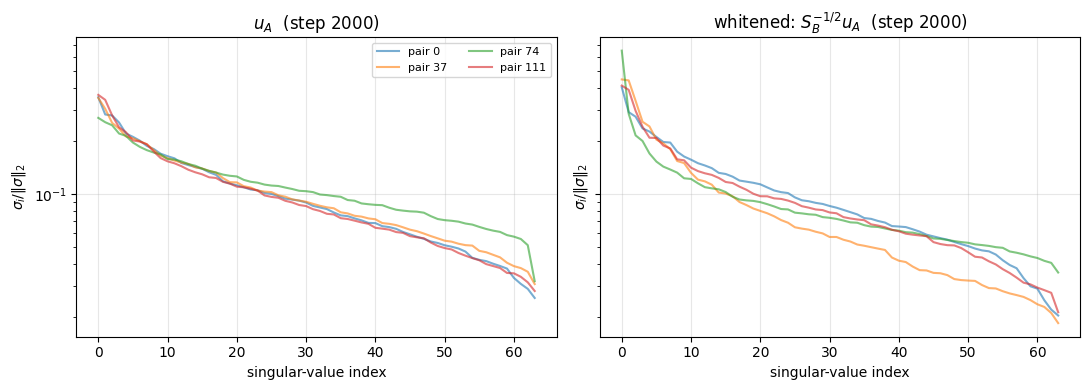

In [2]:
# DELTA_ABS / spd_half_inv / whitened_NS_input live in
# lora_playground.snapshot_analysis.whitening.
def plot_spectra_u_vs_whitened(step, pair_indices=None, n_pairs_to_plot=4, side='A'):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        s_u = normalized_sigmas(p[f'u_{side}'])
        s_w = normalized_sigmas(whitened_NS_input(p, side=side))
        axes[0].plot(s_u, alpha=0.6, label=f'pair {int(pi)}')
        axes[1].plot(s_w, alpha=0.6, label=f'pair {int(pi)}')
    axes[0].set_title(f'$u_{side}$  (step {step})')
    sub = 'B' if side == 'A' else 'A'
    pre = f'S_{sub}^{{-1/2}} u_{side}' if side == 'A' else f'u_{side} S_{sub}^{{-1/2}}'
    axes[1].set_title(f'whitened: ${pre}$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index')
        ax.set_ylabel(r'$\sigma_i / \|\sigma\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

plot_spectra_u_vs_whitened(2000, n_pairs_to_plot=4, side='A')
plt.show()


## Whitened vs unwhitened Newton–Schulz output spectrum

The §9 polar step in chord-tight is **`polar_NS(S_B^{-1/2} @ u_A)`** for the A-side (symmetric for B). The whitening by $S_B^{-1/2}$ is supposed to precondition the spectrum into a regime where NS converges quickly at the production $N_s = 5$.

This cell:
1. Computes the whitened input $X = S_B^{-1/2} u_A$ on each pair using absolute damping $\delta_B = 10^{-6}$ (matches run B's production setting; for run A this is a less-damped counterfactual — see the caveat in the cell above).
2. Runs NS at $N_s \in \{1, 3, 5, 10\}$ on both the **whitened** and the **unwhitened** (raw `u_A`) inputs, Frobenius-normalized at NS entry.
3. Overlays the resulting singular-value curves.

Two reads:
- **Whitening effect**: does $X$ have a tighter spectrum than $u_A$ before NS?
- **NS convergence sanity check**: does the whitened input reach $\sigma \to 1$ by $N_s = 10$? If yes, $N_s = 5$ in production is a deliberate-imprecision choice (paper §3.2: muon tolerates $\varepsilon \approx 0.3$). If no, the whitened spectrum is still too heavy-tailed and NS-K is structurally short.


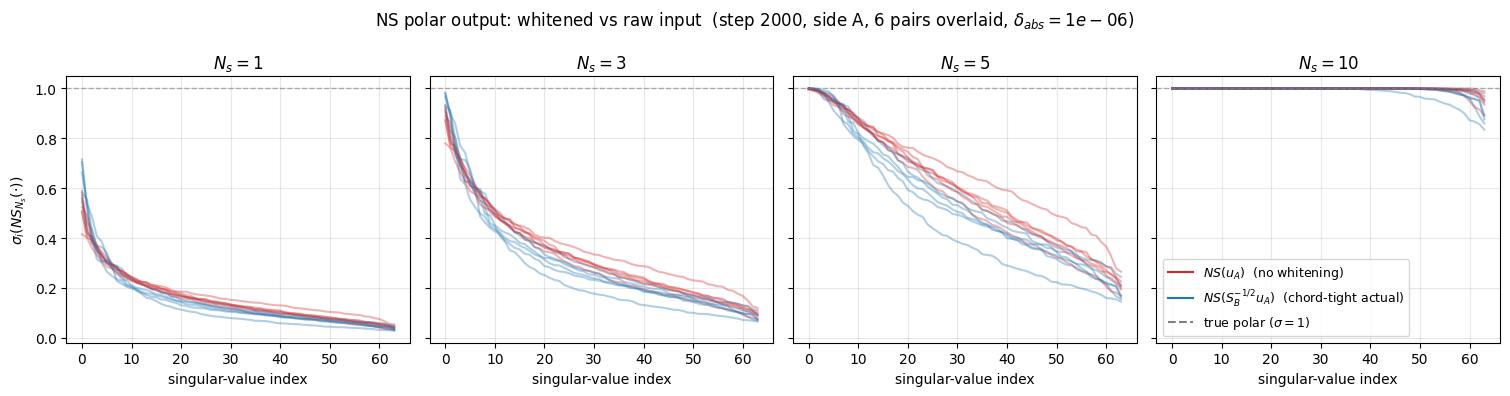

In [3]:
def plot_whitened_vs_naked(step, pair_indices=None, n_pairs=6, side='A',
                           Ks=(1, 3, 5, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(1, len(Ks), figsize=(3.8 * len(Ks), 4),
                             sharey=True, sharex=True)
    for ax, K in zip(axes, Ks):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X_whiten = whitened_NS_input(p, side=side)
            X_naked  = p[f'u_{side}']
            s_w = torch.linalg.svdvals(newton_schulz_polar(X_whiten, K)).numpy()
            s_n = torch.linalg.svdvals(newton_schulz_polar(X_naked,  K)).numpy()
            ax.plot(s_n, color='C3', alpha=0.35)
            ax.plot(s_w, color='C0', alpha=0.35)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
        ax.set_title(f'$N_s = {K}$')
        ax.set_xlabel('singular-value index')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r'$\sigma_i(NS_{N_s}(\cdot))$')
    from matplotlib.lines import Line2D
    axes[-1].legend([Line2D([], [], color='C3'),
                     Line2D([], [], color='C0'),
                     Line2D([], [], color='gray', ls='--')],
                    [r'$NS(u_A)$  (no whitening)',
                     r'$NS(S_B^{-1/2} u_A)$  (chord-tight actual)',
                     r'true polar ($\sigma = 1$)'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'NS polar output: whitened vs raw input  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid, '
                 f'$\\delta_{{abs}} = {DELTA_ABS}$)')
    fig.tight_layout()
    return fig

plot_whitened_vs_naked(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()

### Cross-run: whitened vs raw $u_A$ NS output (lr=3e-2 vs lr=1e-1)

Same layout as `plot_whitened_vs_naked` above, but rows = run.

**Whitening-damping caveat (continued).** Run A's production used relative damping $\delta_B = 10^{-2} \cdot \lambda_{\max}(S_B)$; run B's used absolute $\delta_B = 10^{-6}$. For a like-for-like spectrum comparison we whiten both with the same `delta_abs` (default $10^{-6}$, matching run B exactly and run A only as an analytic counterfactual). This isolates underlying $u_A$ / $S_B$ shape differences across runs rather than damping policy. To replicate run A's production whitening on run A, scale `delta_abs` to $10^{-2} \cdot \lambda_{\max}(S_B)$ per pair.

Caveat carries over from the first cross-run cell: also confounded by `r` (64 vs 256), $N_s$ (5 vs 10), and `chord-tight` vs `chord-tight-clean`.


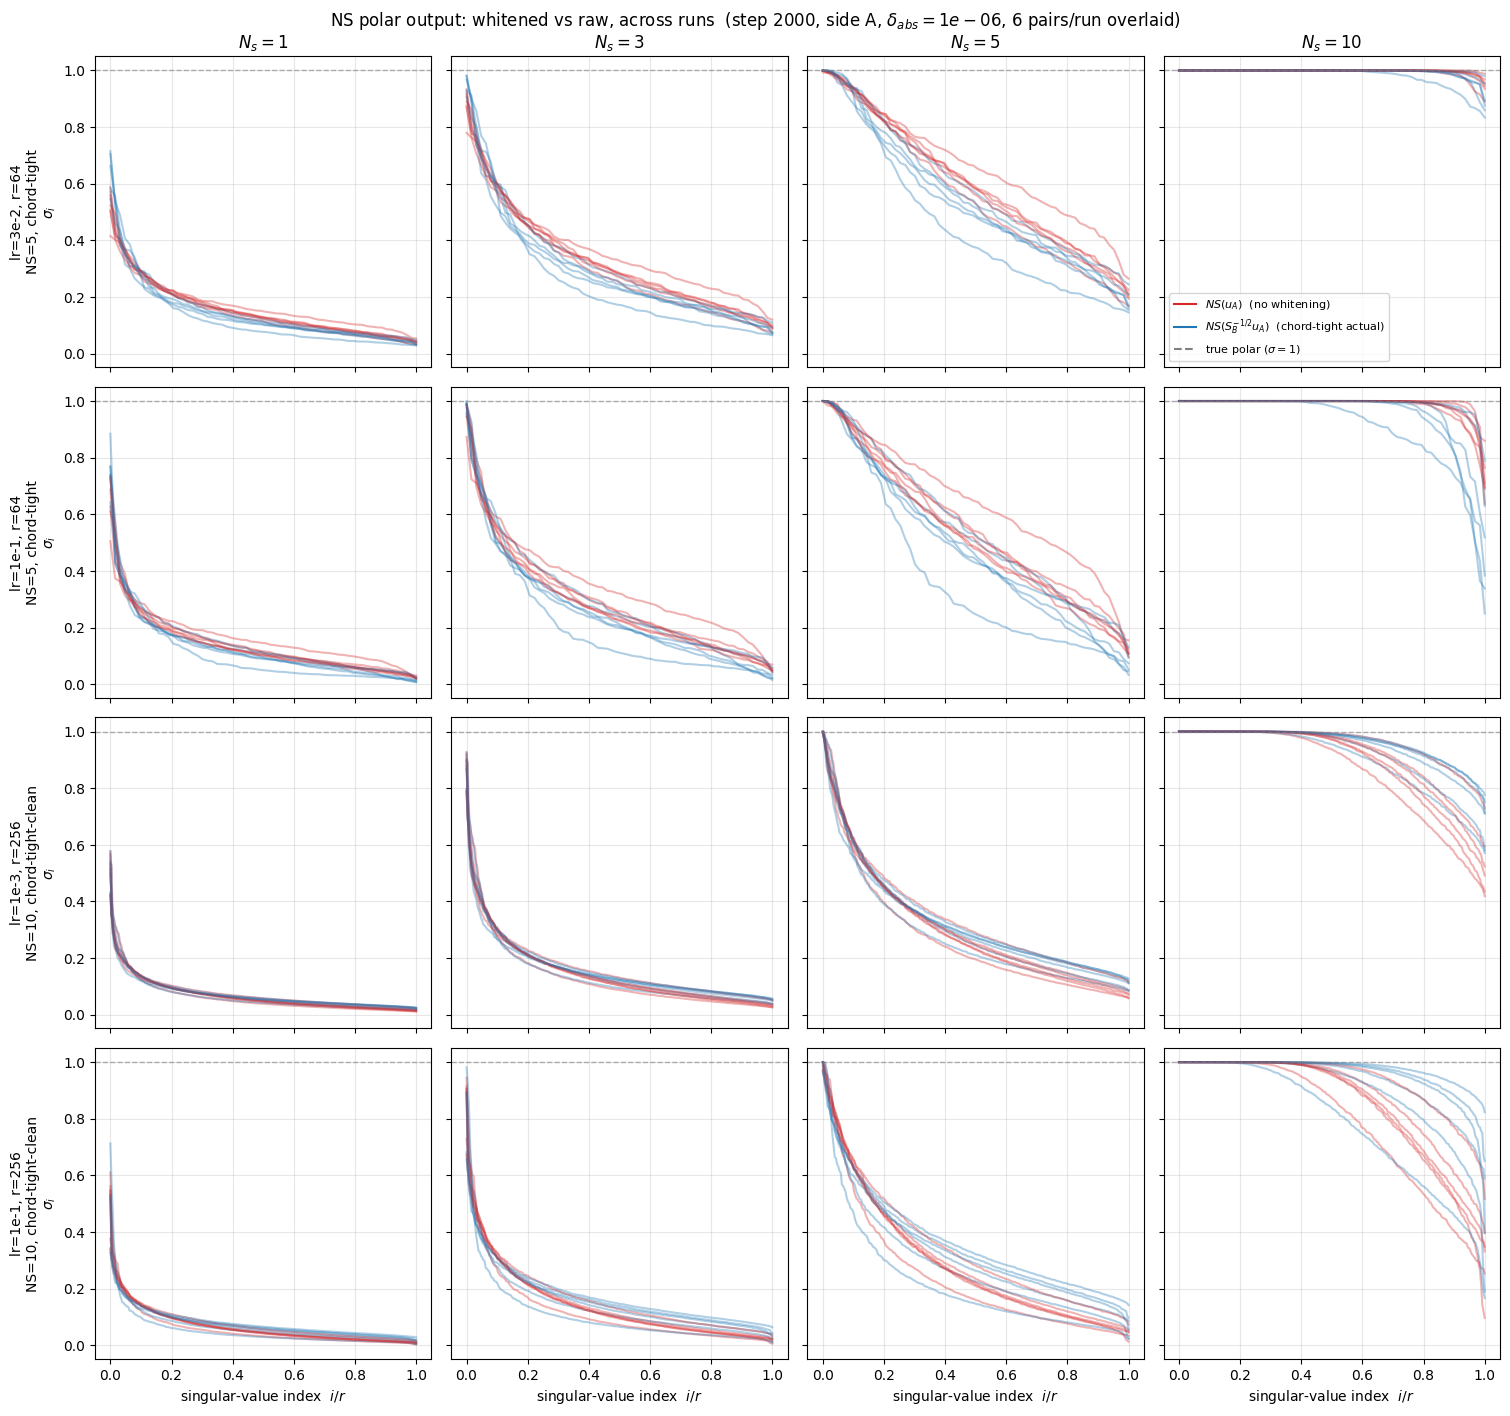

In [4]:
def plot_whitened_vs_naked_compare_runs(step, n_pairs=6, side='A',
                                        Ks=(1, 3, 5, 10), delta_abs=DELTA_ABS):
    runs = RUNS
    fig, axes = plt.subplots(len(runs), len(Ks),
                              figsize=(3.8 * len(Ks), 3.6 * len(runs)),
                              sharex=True, sharey=True)
    for row, run_key in enumerate(runs):
        root = SNAP_ROOTS[run_key]
        snap = load_snapshot(step, root=root)
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
        for col, K in enumerate(Ks):
            ax = axes[row, col]
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                # whitened_NS_input uses module-level DELTA_ABS; do whitening inline
                # so this function takes its own delta_abs kwarg without mutating globals.
                A = p['A'].float(); B = p['B'].float()
                u = p[f'u_{side}'].float()
                S = (B.T @ B) if side == 'A' else (A @ A.T)
                evals, evecs = torch.linalg.eigh(
                    S + delta_abs * torch.eye(S.shape[0], dtype=S.dtype))
                S_half_inv = evecs @ torch.diag(evals.clamp_min(1e-30).rsqrt()) @ evecs.T
                X_whiten = (S_half_inv @ u) if side == 'A' else (u @ S_half_inv)
                X_naked  = u
                s_w = torch.linalg.svdvals(newton_schulz_polar(X_whiten, K)).numpy()
                s_n = torch.linalg.svdvals(newton_schulz_polar(X_naked,  K)).numpy()
                xw = np.arange(len(s_w)) / max(len(s_w) - 1, 1)
                xn = np.arange(len(s_n)) / max(len(s_n) - 1, 1)
                ax.plot(xn, s_n, color='C3', alpha=0.35)
                ax.plot(xw, s_w, color='C0', alpha=0.35)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N_s = {K}$')
            if col == 0:
                ax.set_ylabel(f'lr={run_key[0]}, r={run_key[1]}\n'
                              f'NS={run_key[2]}, {run_key[3]}\n'
                              r'$\sigma_i$')
            if row == len(runs) - 1:
                ax.set_xlabel('singular-value index  $i/r$')
            ax.grid(True, alpha=0.3)
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C0'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'$NS(u_A)$  (no whitening)',
                        r'$NS(S_B^{-1/2} u_A)$  (chord-tight actual)',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=8)
    fig.suptitle(f'NS polar output: whitened vs raw, across runs  '
                 f'(step {step}, side {side}, '
                 rf'$\delta_{{abs}} = {delta_abs}$, {n_pairs} pairs/run overlaid)')
    fig.tight_layout()
    return fig

plot_whitened_vs_naked_compare_runs(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()

### SSC clip-value sweep across runs

Wider $c$ grid plus the lr=1e-1 run B. Rows = run, columns = $c$. Per panel: input $X$ (blue), $H_c(X)$ (green), true polar $UV^T$ (red, $\\sigma = 1$). As $c \\to 0$ SSC pulls all singular values toward zero; as $c \\to \\infty$ SSC tends to identity. The interesting regime is where $c$ sits in $[\\sigma_{\\min}, \\sigma_{\\max}]$ of the production input — that's where clipping does work.


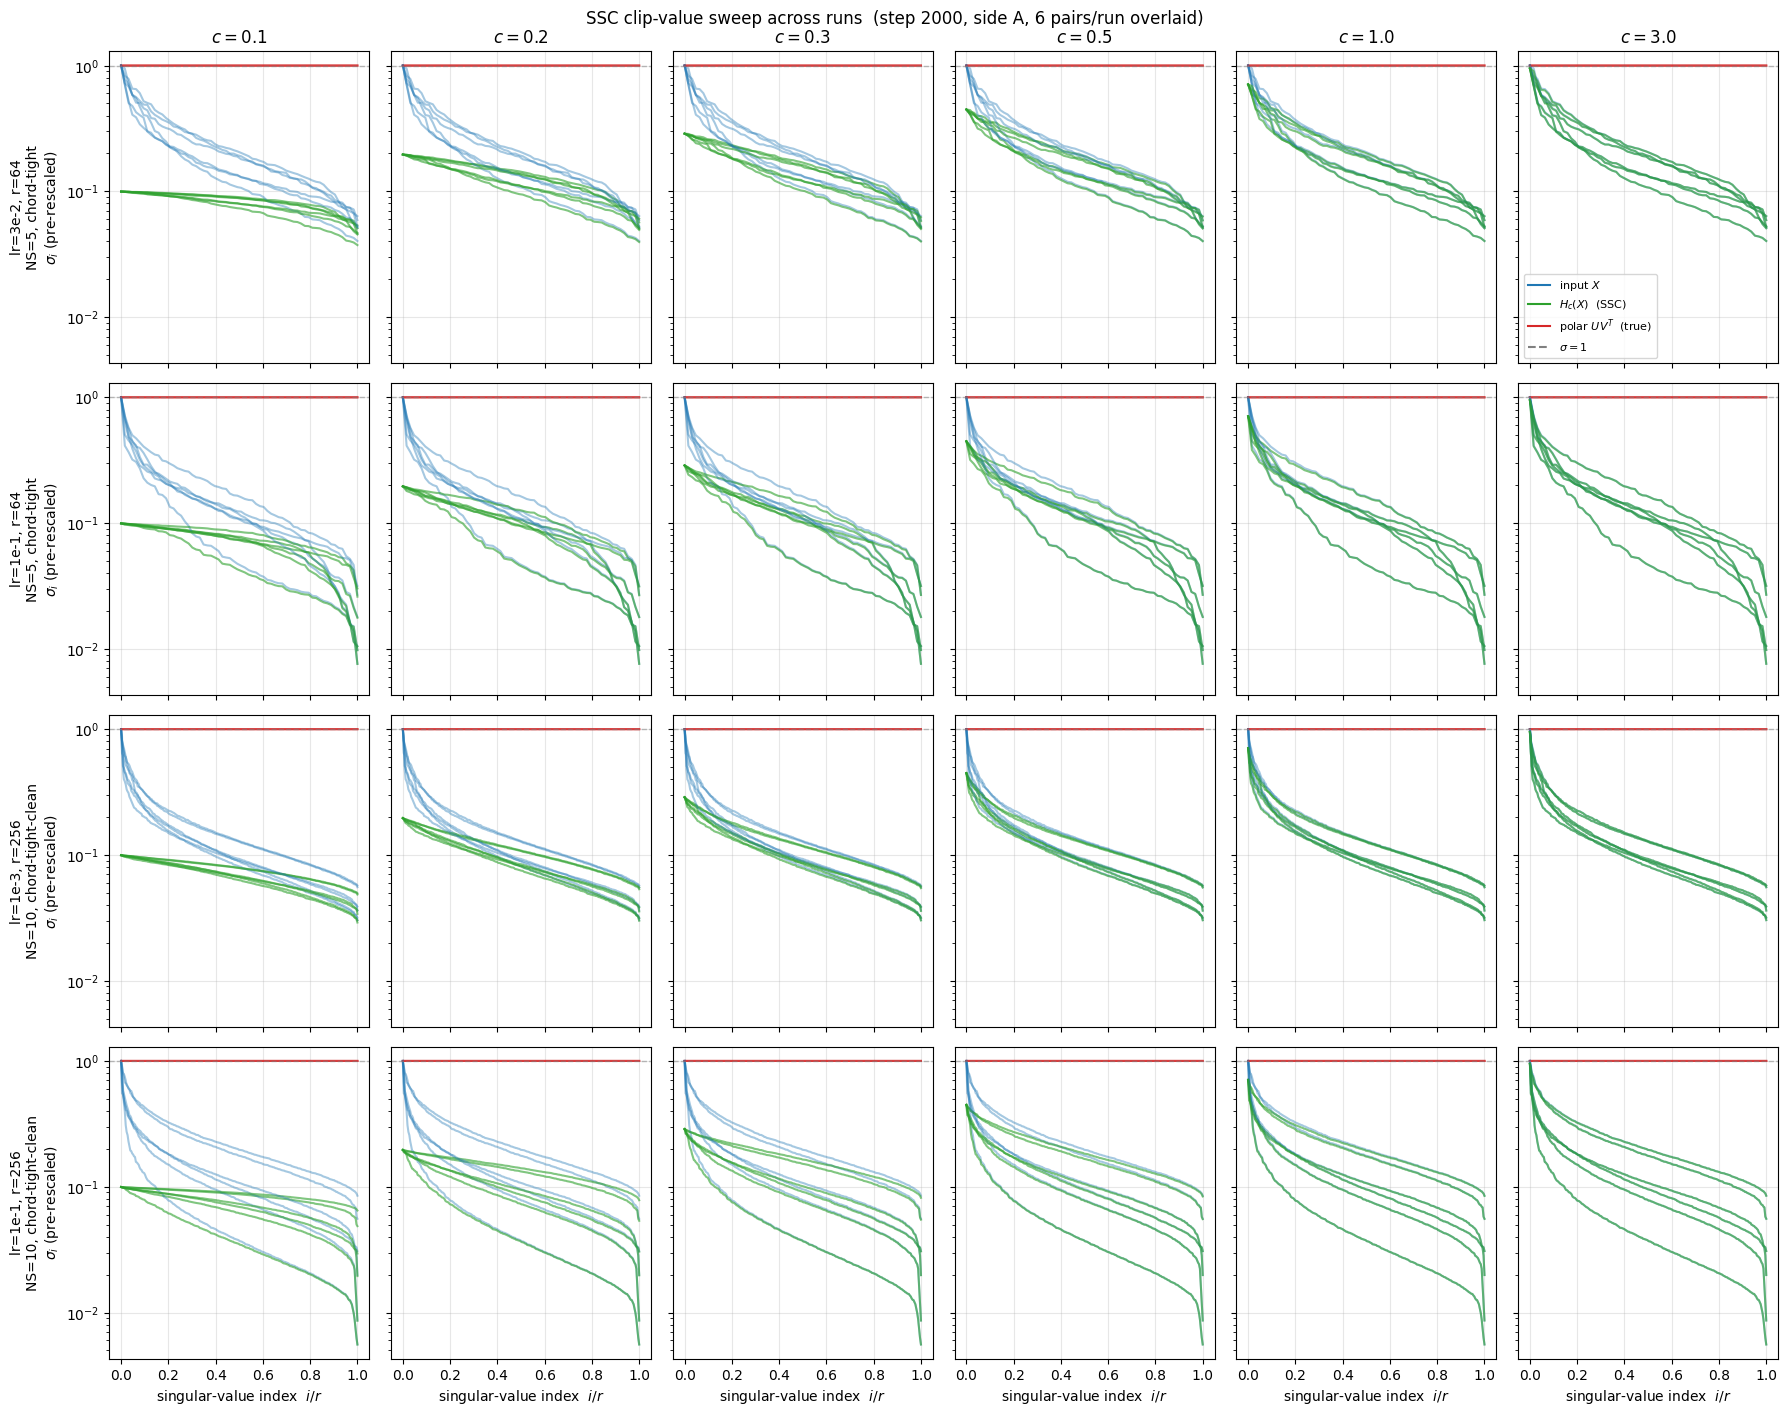

In [5]:
# _prerescale_unit_op / _ssc_svd / _polar_uvt come from lora_playground.snapshot_analysis.
def plot_ssc_compare_runs(step=2000, cs=(0.1, 0.2, 0.3, 0.5, 1.0, 3.0),
                          n_pairs=6, side='A', device=SSC_DEV,
                          delta_abs=DELTA_ABS):
    """SSC spectrum overlay at multiple c values, rows=run."""
    runs = RUNS
    fig, axes = plt.subplots(len(runs), len(cs),
                              figsize=(3.0 * len(cs), 3.6 * len(runs)),
                              sharey=True, sharex=True)
    for row, run_key in enumerate(runs):
        root = SNAP_ROOTS[run_key]
        snap = load_snapshot(step, root=root)
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
        for col, c in enumerate(cs):
            ax = axes[row, col]
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                A = p['A'].float(); B = p['B'].float()
                u = p[f'u_{side}'].float()
                S = (B.T @ B) if side == 'A' else (A @ A.T)
                evals, evecs = torch.linalg.eigh(
                    S + delta_abs * torch.eye(S.shape[0], dtype=S.dtype))
                S_half_inv = evecs @ torch.diag(evals.clamp_min(1e-30).rsqrt()) @ evecs.T
                X_raw = (S_half_inv @ u) if side == 'A' else (u @ S_half_inv)
                X = _prerescale_unit_op(X_raw.to(device))
                s_X = torch.linalg.svdvals(X).cpu().numpy()
                s_H = torch.linalg.svdvals(_ssc_svd(X, c)).cpu().numpy()
                s_P = torch.linalg.svdvals(_polar_uvt(X)).cpu().numpy()
                xX = np.arange(len(s_X)) / max(len(s_X) - 1, 1)
                ax.plot(xX, s_X, color='C0', alpha=0.40)
                ax.plot(xX, s_H, color='C2', alpha=0.60)
                ax.plot(xX, s_P, color='C3', alpha=0.30)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.5, lw=1)
            if row == 0:
                ax.set_title(rf'$c = {c}$')
            if col == 0:
                ax.set_ylabel(f'lr={run_key[0]}, r={run_key[1]}\n'
                              f'NS={run_key[2]}, {run_key[3]}\n'
                              r'$\sigma_i$ (pre-rescaled)')
            if row == len(runs) - 1:
                ax.set_xlabel('singular-value index  $i/r$')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C0'),
                        Line2D([], [], color='C2'),
                        Line2D([], [], color='C3'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'input $X$',
                        r'$H_c(X)$  (SSC)',
                        r'polar $UV^T$  (true)',
                        r'$\sigma = 1$'],
                       loc='lower left', fontsize=8)
    fig.suptitle(f'SSC clip-value sweep across runs  (step {step}, side {side}, '
                 f'{n_pairs} pairs/run overlaid)')
    fig.tight_layout()
    return fig

plot_ssc_compare_runs(2000, cs=(0.1, 0.2, 0.3, 0.5, 1.0, 3.0), n_pairs=6, side='A')
plt.show()

### Equivalent NS-$K$ for SSC at fixed $c$

For a given input $X$ (pre-rescaled so $\|X\|_2 = 1$), both SSC-at-$c$ and NS-at-$K$ produce an output spectrum that pushes the input singular values toward $1$. We can match them by **output stable rank**: define

$$K_{\mathrm{eq}}(c; X) \;:=\; K \text{ such that } r_{\mathrm{eff}}(\mathrm{NS}_K(X)) \,=\, r_{\mathrm{eff}}(\mathrm{SSC}_c(X)), \qquad r_{\mathrm{eff}}(M) = \|M\|_F^2 / \|M\|_{\mathrm{op}}^2.$$

The intuition (per the framework above):
- Flat input spectrum → fixed $c$ acts polar-like → large $K_{\mathrm{eq}}$.
- Spiky input spectrum → fixed $c$ acts identity-like → small $K_{\mathrm{eq}}$.
- Mass near $c$ → $K_{\mathrm{eq}}$ is sensitive to small $c$ shifts.

Columns: (1) NS stable rank vs $K$; (2) SSC stable rank vs $c$; (3) the derived $K_{\mathrm{eq}}(c)$ curve, with horizontal dashed lines at production NS-$K$ values for each run (5 for run A, 10 for run B).

Per-pair curves overlaid, median across pairs in thick line. Rows = run (so you can see if the spiky-vs-flat regime shifts with lr).


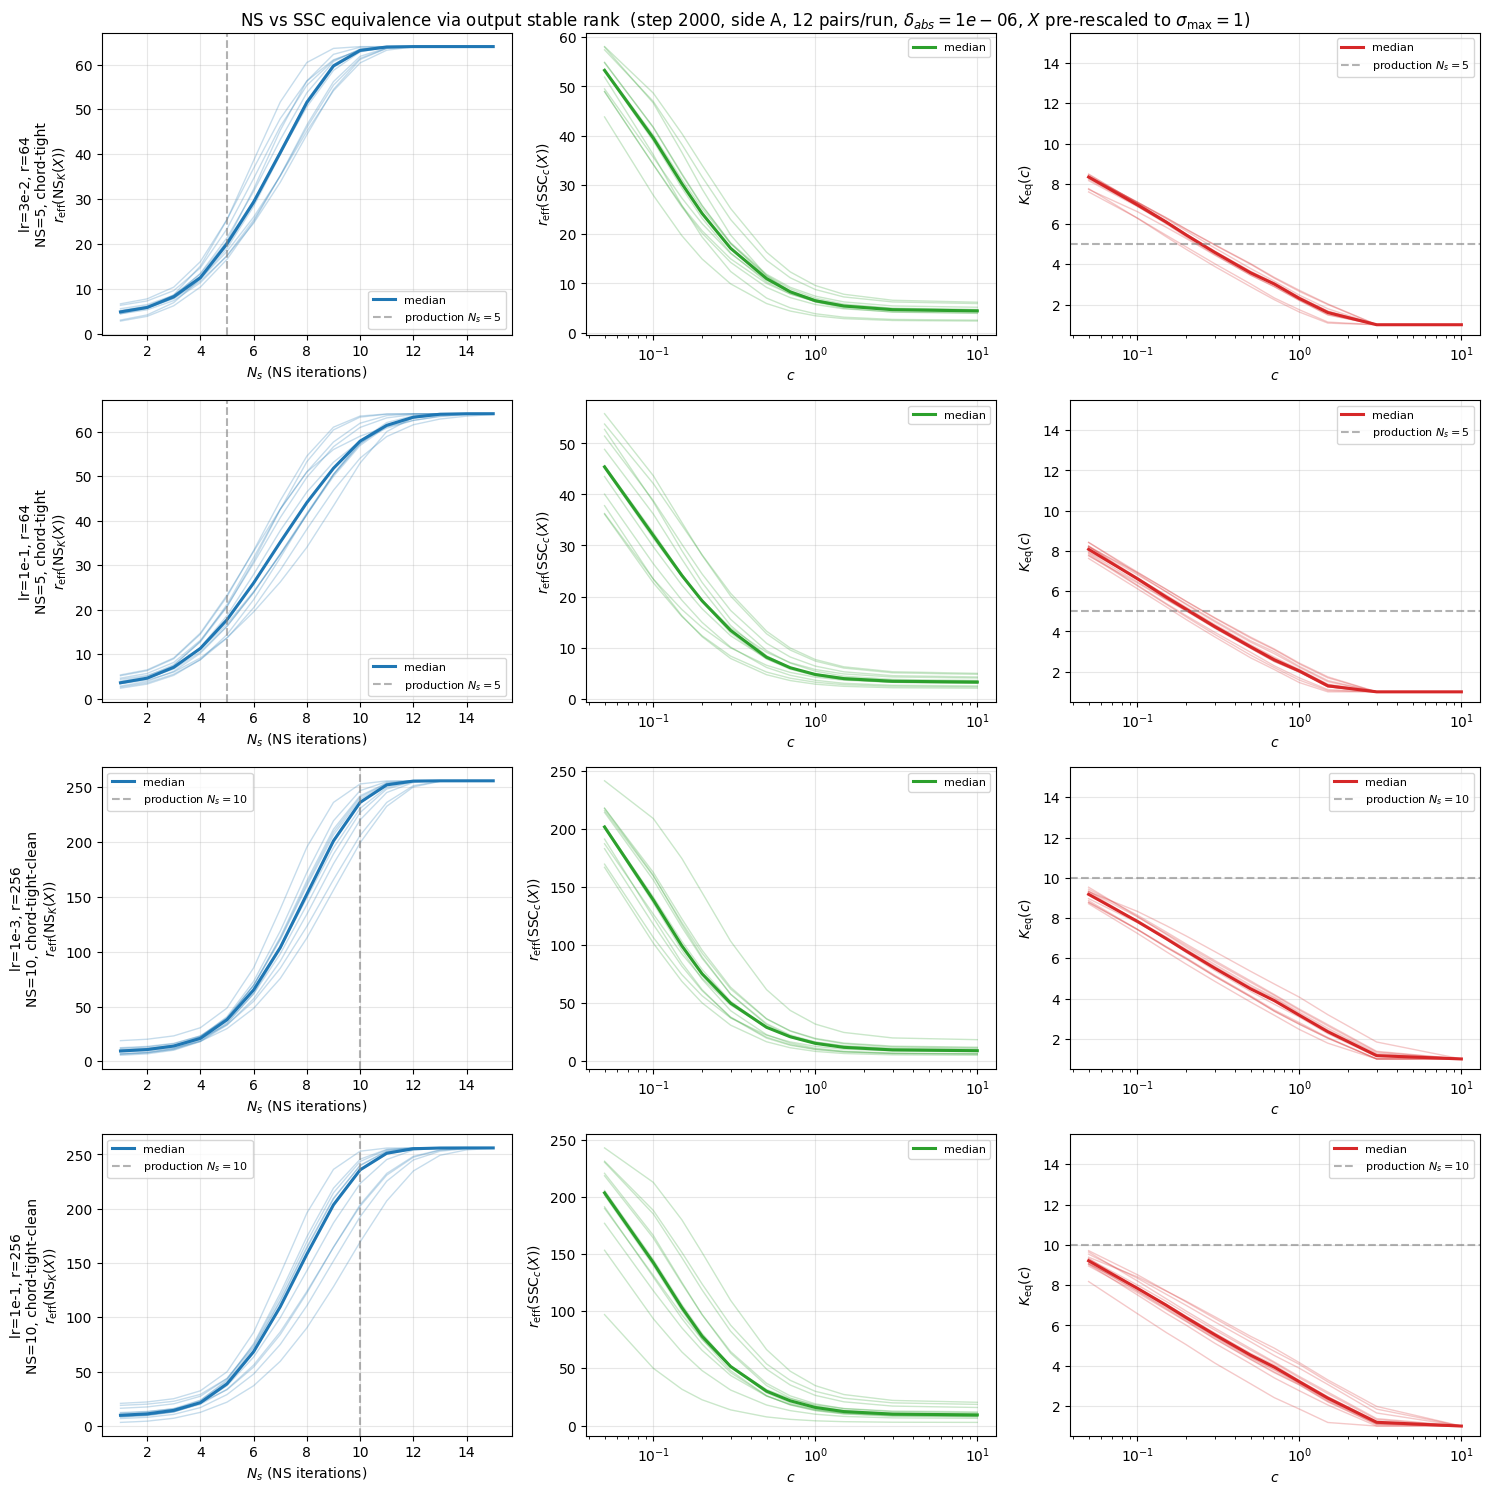

In [6]:
# stable_rank lives in lora_playground.snapshot_analysis.moments.
def plot_Keq_c_compare_runs(step=2000, n_pairs=12, side='A',
                            Ks=tuple(range(1, 16)),
                            cs=(0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 3.0, 10.0),
                            device=SSC_DEV, delta_abs=DELTA_ABS):
    runs = RUNS
    fig, axes = plt.subplots(len(runs), 3, figsize=(15, 3.8 * len(runs)))
    # production NS-K = third tuple entry of each run key (e.g. 5, 10).
    prod_K = {r: r[2] for r in RUNS}

    for row, run_key in enumerate(runs):
        snap = load_snapshot(step, root=SNAP_ROOTS[run_key])
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

        ns_curves   = []   # (n_pairs, len(Ks)) — stable rank
        ssc_curves  = []   # (n_pairs, len(cs))
        keq_curves  = []   # (n_pairs, len(cs))

        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            A = p['A'].float(); B = p['B'].float()
            u = p[f'u_{side}'].float()
            S = (B.T @ B) if side == 'A' else (A @ A.T)
            evals, evecs = torch.linalg.eigh(
                S + delta_abs * torch.eye(S.shape[0], dtype=S.dtype))
            S_half_inv = evecs @ torch.diag(evals.clamp_min(1e-30).rsqrt()) @ evecs.T
            X_raw = (S_half_inv @ u) if side == 'A' else (u @ S_half_inv)
            X = _prerescale_unit_op(X_raw.to(device))

            sr_ns  = np.array([stable_rank(newton_schulz_polar(X, K)) for K in Ks])
            sr_ssc = np.array([stable_rank(_ssc_svd(X, c)) for c in cs])
            # K_eq(c): for each c, find K where NS stable rank equals SSC stable rank.
            # Use linear interp on (K, sr_ns). Clip to [Ks[0], Ks[-1]].
            keq = np.interp(sr_ssc, sr_ns, np.array(Ks),
                            left=Ks[0], right=Ks[-1])
            ns_curves.append(sr_ns)
            ssc_curves.append(sr_ssc)
            keq_curves.append(keq)

        ns_curves  = np.array(ns_curves)
        ssc_curves = np.array(ssc_curves)
        keq_curves = np.array(keq_curves)

        ax_ns, ax_ssc, ax_keq = axes[row]
        for j in range(len(pair_indices)):
            ax_ns.plot(Ks, ns_curves[j],  color='C0', alpha=0.25, lw=1)
            ax_ssc.plot(cs, ssc_curves[j], color='C2', alpha=0.25, lw=1)
            ax_keq.plot(cs, keq_curves[j], color='C3', alpha=0.25, lw=1)
        ax_ns.plot (Ks, np.median(ns_curves, axis=0),  color='C0', lw=2.2, label='median')
        ax_ssc.plot(cs, np.median(ssc_curves, axis=0), color='C2', lw=2.2, label='median')
        ax_keq.plot(cs, np.median(keq_curves, axis=0), color='C3', lw=2.2, label='median')

        ax_ns.set_xlabel('$N_s$ (NS iterations)')
        ax_ns.set_ylabel(f'lr={run_key[0]}, r={run_key[1]}\n'
                         f'NS={run_key[2]}, {run_key[3]}\n'
                         r'$r_{\mathrm{eff}}(\mathrm{NS}_K(X))$')
        ax_ns.axvline(prod_K[run_key], color='gray', ls='--', alpha=0.6,
                      label=f'production $N_s = {prod_K[run_key]}$')
        ax_ns.grid(True, alpha=0.3); ax_ns.legend(fontsize=8)

        ax_ssc.set_xscale('log')
        ax_ssc.set_xlabel('$c$')
        ax_ssc.set_ylabel(r'$r_{\mathrm{eff}}(\mathrm{SSC}_c(X))$')
        ax_ssc.grid(True, alpha=0.3); ax_ssc.legend(fontsize=8)

        ax_keq.set_xscale('log')
        ax_keq.set_xlabel('$c$')
        ax_keq.set_ylabel(r'$K_{\mathrm{eq}}(c)$')
        ax_keq.axhline(prod_K[run_key], color='gray', ls='--', alpha=0.6,
                       label=f'production $N_s = {prod_K[run_key]}$')
        ax_keq.set_ylim(Ks[0] - 0.5, Ks[-1] + 0.5)
        ax_keq.grid(True, alpha=0.3); ax_keq.legend(fontsize=8)

    fig.suptitle(f'NS vs SSC equivalence via output stable rank  '
                 f'(step {step}, side {side}, {n_pairs} pairs/run, '
                 rf'$\delta_{{abs}} = {delta_abs}$, $X$ pre-rescaled to $\sigma_{{\max}} = 1$)')
    fig.tight_layout()
    return fig

plot_Keq_c_compare_runs(2000, n_pairs=12, side='A')
plt.show()

### Polar Express on whitened vs raw $u_A$

Same NS-vs-PE overlay as above, but on the §9 production inputs: bias-corrected Adam direction $u_A$ and its whitened form $S_B^{-1/2} u_A$.

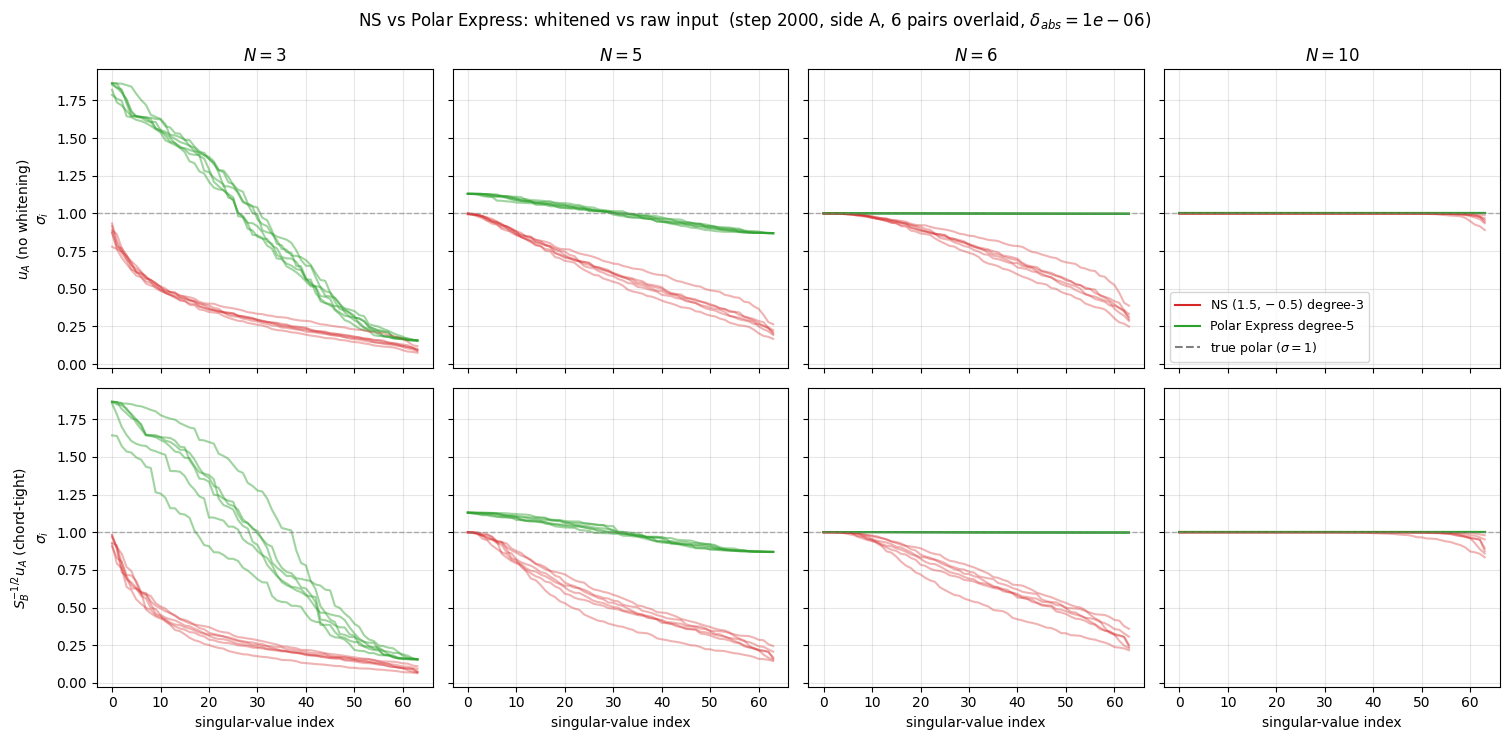

In [7]:
def plot_pe_vs_ns_whitened(step, pair_indices=None, n_pairs=6, side='A',
                           Ks=(3, 5, 8, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(2, len(Ks), figsize=(3.8 * len(Ks), 7.5),
                             sharey=True, sharex=True)
    for row, (input_kind, label) in enumerate([
        ('naked',   r'$u_A$ (no whitening)'),
        ('whiten',  r'$S_B^{-1/2} u_A$ (chord-tight)'),
    ]):
        for ax, K in zip(axes[row], Ks):
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                X = (p[f'u_{side}'] if input_kind == 'naked'
                     else whitened_NS_input(p, side=side))
                s_ns = torch.linalg.svdvals(newton_schulz_polar(X, K)).numpy()
                s_pe = torch.linalg.svdvals(polar_express(X, K)).numpy()
                ax.plot(s_ns, color='C3', alpha=0.35)
                ax.plot(s_pe, color='C2', alpha=0.45)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N = {K}$')
            ax.grid(True, alpha=0.3)
        axes[row, 0].set_ylabel(label + '\n' + r'$\sigma_i$')
    for ax in axes[-1]:
        ax.set_xlabel('singular-value index')
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C2'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'NS $(1.5, -0.5)$ degree-3',
                        r'Polar Express degree-5',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=9)
    fig.suptitle(f'NS vs Polar Express: whitened vs raw input  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid, '
                 rf'$\delta_{{abs}} = {DELTA_ABS}$)')
    fig.tight_layout()
    return fig

plot_pe_vs_ns_whitened(2000, n_pairs=6, side='A', Ks=(3, 5, 6, 10))
plt.show()
